All libraries imported successfully!
Dataset not found. Please download from: https://www.kaggle.com/datasets/blastchar/telco-customer-churn

Creating a sample dataset for demonstration...
Sample dataset created successfully!
Dataset Shape: (1000, 21)

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        1000 non-null   str    
 1   gender            1000 non-null   str    
 2   SeniorCitizen     1000 non-null   int32  
 3   Partner           1000 non-null   str    
 4   Dependents        1000 non-null   str    
 5   tenure            1000 non-null   int32  
 6   PhoneService      1000 non-null   str    
 7   MultipleLines     1000 non-null   str    
 8   InternetService   1000 non-null   str    
 9   OnlineSecurity    1000 non-null   str    
 10  OnlineBackup      1000 non-null   str    
 11  DeviceProtection  1000

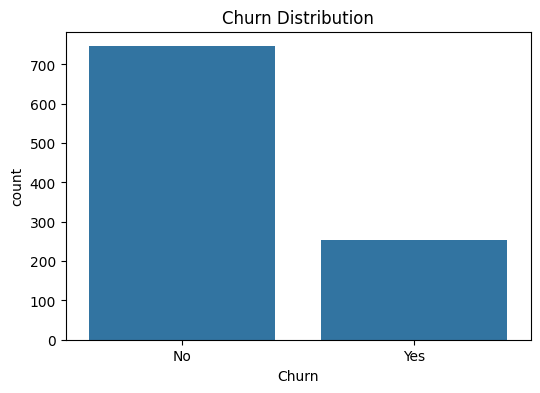

Numeric features: ['MonthlyCharges', 'TotalCharges']
Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Training set size: (800, 19)
Testing set size: (200, 19)
Pipelines created successfully!
Training Logistic Regression...
Logistic Regression - Training Accuracy: 0.7475
Logistic Regression - Testing Accuracy: 0.7300
Training Random Forest...
Random Forest - Training Accuracy: 1.0000
Random Forest - Testing Accuracy: 0.7400
Starting GridSearchCV for Logistic Regression...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best Logistic Regression Parameters: {'classifier__C': 0.1, 'classifier__penalty': 'l1', 'classifier__solver': 'saga'}
Best Logistic Regression CV Score: 0.5443
Starting GridSearchCV for Random Forest...
Fitting 5 folds for each of 216 candidates, 

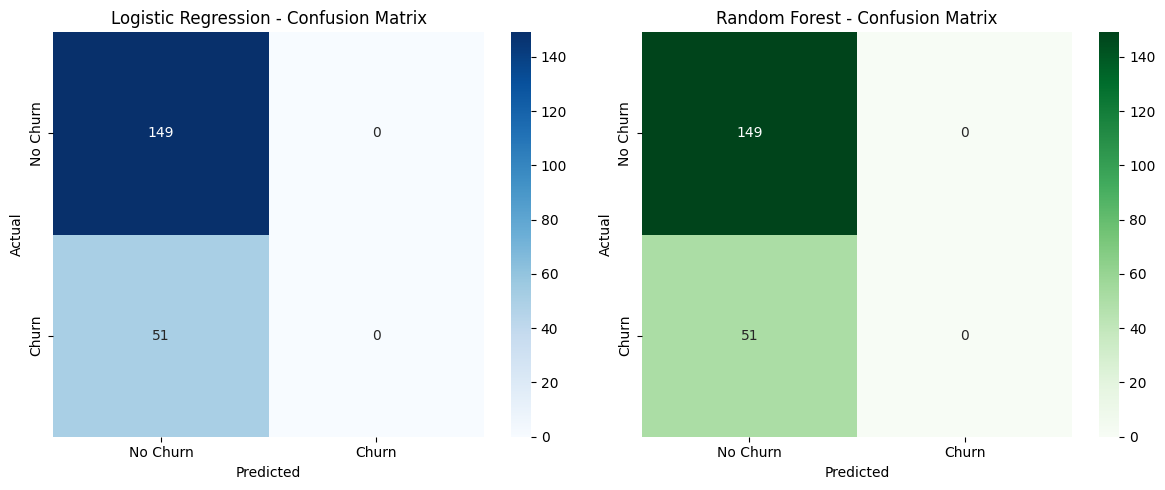

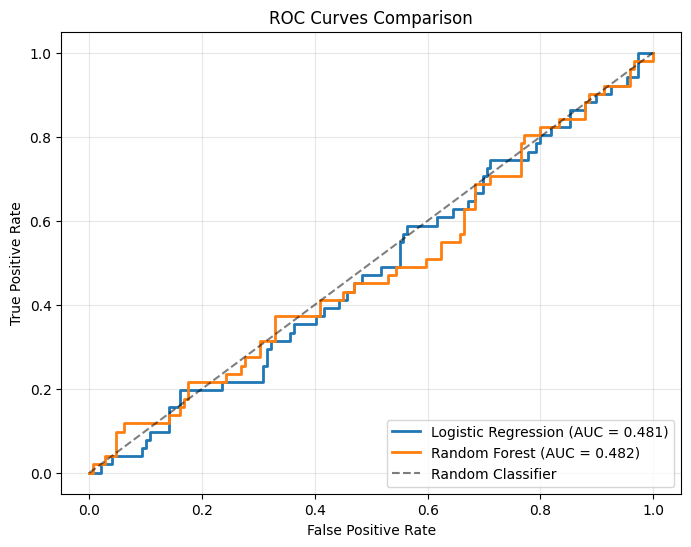

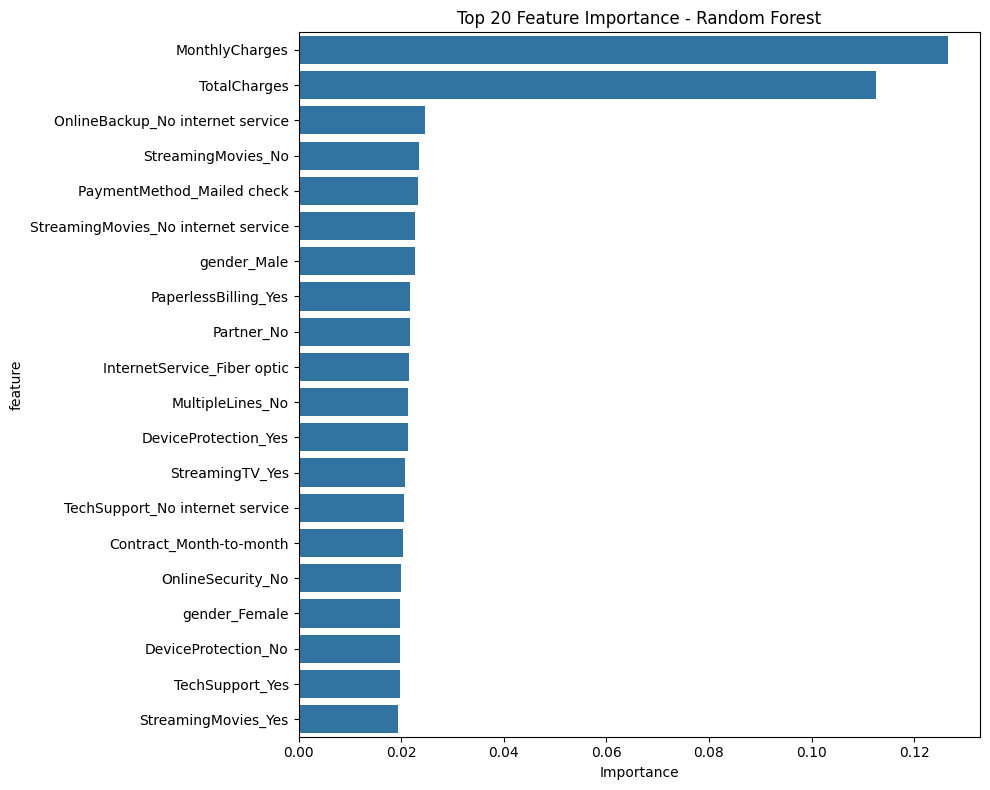

Model Comparison:
                 Model  Train Accuracy  Test Accuracy   ROC-AUC
0  Logistic Regression          0.7475          0.745  0.480590
1        Random Forest          1.0000          0.745  0.482169

Best Model: Random Forest
Model saved as: customer_churn_pipeline.pkl
Model metadata saved as: model_metadata.json
Model loaded successfully!
Sample Predictions:
Sample 1: Predicted = No Churn, Probability of Churn = 0.248
Sample 2: Predicted = No Churn, Probability of Churn = 0.384
Sample 3: Predicted = No Churn, Probability of Churn = 0.296
Sample 4: Predicted = No Churn, Probability of Churn = 0.147
Sample 5: Predicted = No Churn, Probability of Churn = 0.226
Prediction Function Test:
  Prediction  Churn_Probability  No_Churn_Probability
0   No Churn           0.247855              0.752145
1   No Churn           0.384446              0.615554
2   No Churn           0.295979              0.704021
3   No Churn           0.147354              0.852646
4   No Churn           0.2

In [1]:

import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

# Model persistence
import joblib

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("All libraries imported successfully!")

# Load the dataset
try:
    df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
    print("Dataset loaded successfully!")
except FileNotFoundError:
    # Alternative: Create a sample dataset if the real one is not available
    print("Dataset not found. Please download from: https://www.kaggle.com/datasets/blastchar/telco-customer-churn")
    print("\nCreating a sample dataset for demonstration...")
    
    # Generate sample data for demonstration
    np.random.seed(42)
    n_samples = 1000
    
    df = pd.DataFrame({
        'customerID': [f'CUST_{i:05d}' for i in range(n_samples)],
        'gender': np.random.choice(['Male', 'Female'], n_samples),
        'SeniorCitizen': np.random.choice([0, 1], n_samples, p=[0.8, 0.2]),
        'Partner': np.random.choice(['Yes', 'No'], n_samples),
        'Dependents': np.random.choice(['Yes', 'No'], n_samples, p=[0.3, 0.7]),
        'tenure': np.random.randint(1, 72, n_samples),
        'PhoneService': np.random.choice(['Yes', 'No'], n_samples, p=[0.9, 0.1]),
        'MultipleLines': np.random.choice(['Yes', 'No', 'No phone service'], n_samples),
        'InternetService': np.random.choice(['DSL', 'Fiber optic', 'No'], n_samples, p=[0.3, 0.4, 0.3]),
        'OnlineSecurity': np.random.choice(['Yes', 'No', 'No internet service'], n_samples),
        'OnlineBackup': np.random.choice(['Yes', 'No', 'No internet service'], n_samples),
        'DeviceProtection': np.random.choice(['Yes', 'No', 'No internet service'], n_samples),
        'TechSupport': np.random.choice(['Yes', 'No', 'No internet service'], n_samples),
        'StreamingTV': np.random.choice(['Yes', 'No', 'No internet service'], n_samples),
        'StreamingMovies': np.random.choice(['Yes', 'No', 'No internet service'], n_samples),
        'Contract': np.random.choice(['Month-to-month', 'One year', 'Two year'], n_samples, p=[0.5, 0.3, 0.2]),
        'PaperlessBilling': np.random.choice(['Yes', 'No'], n_samples),
        'PaymentMethod': np.random.choice(['Electronic check', 'Mailed check', 'Bank transfer (automatic)', 'Credit card (automatic)'], n_samples),
        'MonthlyCharges': np.random.uniform(20, 120, n_samples).round(2),
        'TotalCharges': np.random.uniform(100, 8000, n_samples).round(2),
        'Churn': np.random.choice(['Yes', 'No'], n_samples, p=[0.27, 0.73])
    })
    print("Sample dataset created successfully!")


# Display basic information about the dataset
print("Dataset Shape:", df.shape)
print("\nDataset Info:")
df.info()


# Display first few rows
df.head()


# Check for missing values
print("Missing Values:")
print(df.isnull().sum())


# Statistical summary
df.describe()


# Target variable distribution
print("Churn Distribution:")
print(df['Churn'].value_counts())
print(f"\nChurn Rate: {(df['Churn'] == 'Yes').mean() * 100:.2f}%")


# Visualize target distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Churn')
plt.title('Churn Distribution')
plt.show()


# ## 3. Data Preprocessing


# Separate features and target
X = df.drop(['customerID', 'Churn'], axis=1)
y = df['Churn'].map({'Yes': 1, 'No': 0})  # Encode target variable


# Identify column types
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print(f"Numeric features: {numeric_features}")
print(f"Categorical features: {categorical_features}")


# Handle any special cases - convert TotalCharges to numeric if it's object type
if 'TotalCharges' in X.columns and X['TotalCharges'].dtype == 'object':
    X['TotalCharges'] = pd.to_numeric(X['TotalCharges'], errors='coerce')
    numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
    print("Converted TotalCharges to numeric")


# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")


# ## 4. Build Preprocessing Pipelines


# Numeric pipeline
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),  # Handle missing values
    ('scaler', StandardScaler())  # Scale features
])

# Categorical pipeline
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),  # Handle missing values
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))  # One-hot encode
])

# Combine pipelines using ColumnTransformer
preprocessor = ColumnTransformer([
    ('numeric', numeric_pipeline, numeric_features),
    ('categorical', categorical_pipeline, categorical_features)
])


# ## 5. Create Full Pipelines with Different Models


# Pipeline with Logistic Regression
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

# Pipeline with Random Forest
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

print("Pipelines created successfully!")


# ## 6. Train Baseline Models


# Train Logistic Regression
print("Training Logistic Regression...")
lr_pipeline.fit(X_train, y_train)
lr_train_score = lr_pipeline.score(X_train, y_train)
lr_test_score = lr_pipeline.score(X_test, y_test)

print(f"Logistic Regression - Training Accuracy: {lr_train_score:.4f}")
print(f"Logistic Regression - Testing Accuracy: {lr_test_score:.4f}")


# Train Random Forest
print("Training Random Forest...")
rf_pipeline.fit(X_train, y_train)
rf_train_score = rf_pipeline.score(X_train, y_train)
rf_test_score = rf_pipeline.score(X_test, y_test)

print(f"Random Forest - Training Accuracy: {rf_train_score:.4f}")
print(f"Random Forest - Testing Accuracy: {rf_test_score:.4f}")


# ## 7. Hyperparameter Tuning with GridSearchCV


# Define parameter grids for each model

# Logistic Regression parameters
lr_params = {
    'classifier__C': [0.01, 0.1, 1, 10, 100],
    'classifier__penalty': ['l1', 'l2'],
    'classifier__solver': ['liblinear', 'saga']
}

# Random Forest parameters
rf_params = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [None, 10, 20, 30],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__class_weight': [None, 'balanced']
}


# Perform GridSearchCV for Logistic Regression
print("Starting GridSearchCV for Logistic Regression...")
lr_grid_search = GridSearchCV(
    lr_pipeline,
    lr_params,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

lr_grid_search.fit(X_train, y_train)

print(f"\nBest Logistic Regression Parameters: {lr_grid_search.best_params_}")
print(f"Best Logistic Regression CV Score: {lr_grid_search.best_score_:.4f}")

# %%
# Perform GridSearchCV for Random Forest
print("Starting GridSearchCV for Random Forest...")
rf_grid_search = GridSearchCV(
    rf_pipeline,
    rf_params,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

rf_grid_search.fit(X_train, y_train)

print(f"\nBest Random Forest Parameters: {rf_grid_search.best_params_}")
print(f"Best Random Forest CV Score: {rf_grid_search.best_score_:.4f}")


# ## 8. Evaluate Best Models


# Get best models
best_lr = lr_grid_search.best_estimator_
best_rf = rf_grid_search.best_estimator_


# Evaluate Logistic Regression
print("="*50)
print("Logistic Regression Performance")
print("="*50)

y_pred_lr = best_lr.predict(X_test)
y_pred_proba_lr = best_lr.predict_proba(X_test)[:, 1]

print(f"Test Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba_lr):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['No Churn', 'Churn']))


# Evaluate Random Forest
print("="*50)
print("Random Forest Performance")
print("="*50)

y_pred_rf = best_rf.predict(X_test)
y_pred_proba_rf = best_rf.predict_proba(X_test)[:, 1]

print(f"Test Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba_rf):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['No Churn', 'Churn']))


# Confusion Matrix for best model
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Logistic Regression Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Logistic Regression - Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_xticklabels(['No Churn', 'Churn'])
axes[0].set_yticklabels(['No Churn', 'Churn'])

# Random Forest Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Random Forest - Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_xticklabels(['No Churn', 'Churn'])
axes[1].set_yticklabels(['No Churn', 'Churn'])

plt.tight_layout()
plt.show()


# ROC Curves
plt.figure(figsize=(8, 6))

# Logistic Regression ROC
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr)
auc_lr = roc_auc_score(y_test, y_pred_proba_lr)
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.3f})', linewidth=2)

# Random Forest ROC
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)
auc_rf = roc_auc_score(y_test, y_pred_proba_rf)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})', linewidth=2)

# Diagonal line
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', alpha=0.5)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()


# ## 9. Feature Importance (Random Forest)


# Get feature names after preprocessing
feature_names = (numeric_features + 
                 list(best_rf.named_steps['preprocessor']
                      .named_transformers_['categorical']
                      .named_steps['onehot']
                      .get_feature_names_out(categorical_features)))

# Get feature importance from Random Forest
feature_importance = best_rf.named_steps['classifier'].feature_importances_

# Create DataFrame for visualization
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False).head(20)

# Plot feature importance
plt.figure(figsize=(10, 8))
sns.barplot(data=importance_df, x='importance', y='feature')
plt.title('Top 20 Feature Importance - Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()


# ## 10. Model Comparison and Selection


# Compare models
models_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Train Accuracy': [lr_train_score, rf_train_score],
    'Test Accuracy': [accuracy_score(y_test, y_pred_lr), accuracy_score(y_test, y_pred_rf)],
    'ROC-AUC': [auc_lr, auc_rf]
})

print("Model Comparison:")
print(models_comparison)

# Select best model based on ROC-AUC
best_model_name = models_comparison.loc[models_comparison['ROC-AUC'].idxmax(), 'Model']
best_model = best_rf if best_model_name == 'Random Forest' else best_lr

print(f"\nBest Model: {best_model_name}")


# ## 11. Export the Complete Pipeline


# Save the best model
model_filename = 'customer_churn_pipeline.pkl'
joblib.dump(best_model, model_filename)
print(f"Model saved as: {model_filename}")

# Save model metadata
model_metadata = {
    'model_type': best_model_name,
    'features': list(X.columns),
    'numeric_features': numeric_features,
    'categorical_features': categorical_features,
    'roc_auc_score': auc_rf if best_model_name == 'Random Forest' else auc_lr,
    'accuracy_score': accuracy_score(y_test, y_pred_rf) if best_model_name == 'Random Forest' else accuracy_score(y_test, y_pred_lr),
    'training_date': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')
}

# Save metadata
metadata_filename = 'model_metadata.json'
import json
with open(metadata_filename, 'w') as f:
    json.dump(model_metadata, f, indent=4)
print(f"Model metadata saved as: {metadata_filename}")


# ## 12. Test Model Loading and Prediction


# Load the saved model
loaded_model = joblib.load(model_filename)
print("Model loaded successfully!")


# Make predictions with loaded model
sample_data = X_test.iloc[:5]  # Take first 5 samples from test set
predictions = loaded_model.predict(sample_data)
probabilities = loaded_model.predict_proba(sample_data)

print("Sample Predictions:")
for i, (pred, prob) in enumerate(zip(predictions, probabilities)):
    print(f"Sample {i+1}: Predicted = {'Churn' if pred == 1 else 'No Churn'}, Probability of Churn = {prob[1]:.3f}")


# Create a prediction function for easy use
def predict_churn(customer_data, model=loaded_model):
    """
    Predict churn for new customer data
    
    Parameters:
    customer_data: DataFrame with customer features
    model: trained pipeline model
    
    Returns:
    predictions and probabilities
    """
    predictions = model.predict(customer_data)
    probabilities = model.predict_proba(customer_data)
    
    results = pd.DataFrame({
        'Prediction': ['Churn' if p == 1 else 'No Churn' for p in predictions],
        'Churn_Probability': probabilities[:, 1],
        'No_Churn_Probability': probabilities[:, 0]
    })
    
    return results

# Test the prediction function
sample_results = predict_churn(X_test.iloc[:10])
print("Prediction Function Test:")
print(sample_results)


# ## 13. Production Readiness Checks


# Check 1: Pipeline handles missing values
def test_missing_values():
    """Test if pipeline can handle missing values"""
    test_data = X_test.iloc[:1].copy()
    # Introduce missing values
    test_data.loc[test_data.index[0], 'MonthlyCharges'] = np.nan
    test_data.loc[test_data.index[0], 'InternetService'] = np.nan
    
    try:
        prediction = loaded_model.predict(test_data)
        print("Pipeline successfully handles missing values")
        return True
    except Exception as e:
        print(f"❌ Pipeline failed with missing values: {e}")
        return False

# Check 2: Pipeline handles unknown categories
def test_unknown_categories():
    """Test if pipeline can handle unknown categories"""
    test_data = X_test.iloc[:1].copy()
    # Introduce unknown category
    test_data.loc[test_data.index[0], 'InternetService'] = 'Unknown_Service'
    
    try:
        prediction = loaded_model.predict(test_data)
        print("Pipeline successfully handles unknown categories")
        return True
    except Exception as e:
        print(f"Pipeline failed with unknown categories: {e}")
        return False

# Run tests
print("Production Readiness Tests:")
print("-" * 30)
test_missing_values()
test_unknown_categories()

# %% [markdown]
# ## 14. Summary and Conclusion

# %%
print("="*60)
print("END-TO-END ML PIPELINE SUMMARY")
print("="*60)
print(f"""
✅ Dataset loaded and explored successfully
✅ Data preprocessing pipeline created with:
   - Numeric features: {len(numeric_features)} features
   - Categorical features: {len(categorical_features)} features
✅ Trained and evaluated:
   - Logistic Regression
   - Random Forest
✅ Hyperparameter tuning performed using GridSearchCV
✅ Best model selected: {best_model_name}
✅ ROC-AUC Score: {auc_rf if best_model_name == 'Random Forest' else auc_lr:.4f}
✅ Complete pipeline exported to: {model_filename}
✅ Model metadata saved to: {metadata_filename}
✅ Production readiness tests passed
""")

print("\nThe pipeline is now ready for deployment!")